# Slow farmer Kolmogorov equations for $N_w$ only

In [1]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [2]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [3]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [4]:
R = 0.00888
K = 0.00772

## setting up system

In [5]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [6]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

In [7]:
def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

In [8]:
def quasiEqRec(N, A):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    #concatenate a zero to the beginning to represent p_0=0
    #important for use with pmfE() and pmfVar(), which assume that p_i appears at index i
    return np.concatenate((np.array([0]), np.linalg.solve(mat, b)))

In [9]:
def rMatrix(N, A, init="quasi"):

    if init=="quasi":
        p = quasiEqRec(N, A)
        
    elif init=="numerical":
        #get numerical solution
        with open("kolmogorov_sol_100.dat", "rb") as f:
            sol_100 = pickle.load(f)

        #get the solution at final time
        p = sol_100[str(N)]["y"][:,-1]
    else:
        raise ValueError("init must be 'quasi' or 'numerical'")

    #function to allow subscipting p outside of 0 <= x <= A
    def p_x(x):
        if x > A or x < 0:
            return 0
        else:
            return p[x]

    def r_ij(i, j):
        if i == j:
            return np.sum([
                -p_x(x)*growthRate(x, N, A)
                -p_x(x)*eatRate(x, N, A)
                +p_x(x-1)*growthRate(x-1, N, A)
                +p_x(x+1)*eatRate(x+1, N, A)*i/N
                for x in range(0, A+1)
            ])
        elif i == j-1:
            return np.sum([
                p_x(y+1)*eatRate(y+1, N, A)*(N-j+1)/N for y in range(0, A+1)
            ])
        else:
            return 0

    r_matrix = np.zeros((N+1, N+1))

    for i in range(0, N+1):
        for j in range(0, N+1):
            r_matrix[i,j] = r_ij(i, j)

    return r_matrix

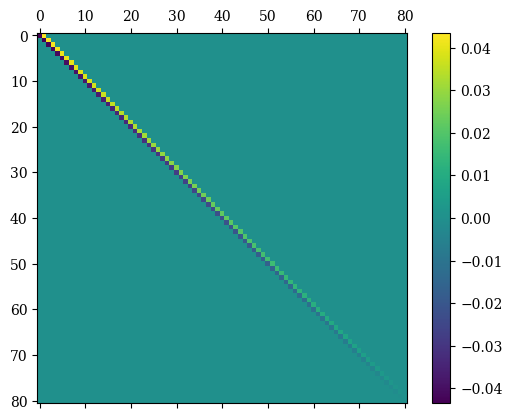

In [10]:
r = rMatrix(80, 100, "quasi")

f, ax = plt.subplots()

im = ax.matshow(r)

plt.colorbar(im)

In [11]:
def simulate(N, A, stoptime, init="quasi"):

    r_matrix = rMatrix(N, A, init)

    q0 = np.zeros(N+1)
    #begin pasture Nw=0
    #meaning q_0 = 1
    q0[0]=1

    def sys(t, y):
        return np.matmul(y, r_matrix)

    #specify T_list to ensure data at T=1
    t_list = np.concatenate((np.arange(0, 11), np.arange(100, stoptime+1, 100)))
    
    st = time.time()

    s = sp.integrate.solve_ivp(sys, (0, stoptime), q0, t_eval = t_list)
    print("finished solution N={0}, A={1} in {2:.2f} seconds".format(N, A, time.time()-st))

    return s

finished solution N=60, A=100 in 0.01 seconds


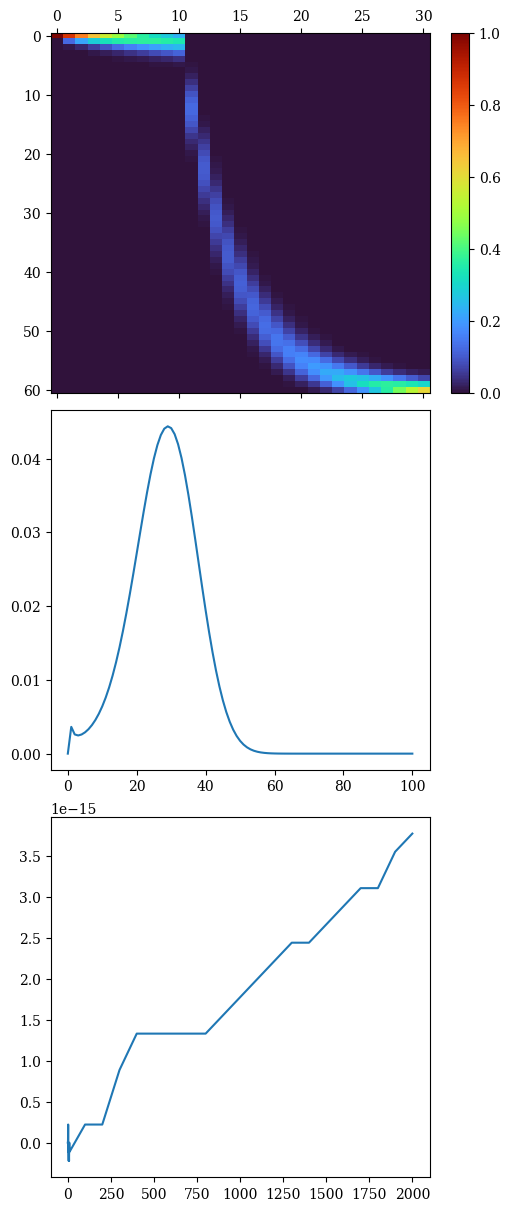

In [12]:
n=60
a=100
b = simulate(n, a, 2000, "numerical")

f, (ax, ax2, ax3) = plt.subplots(nrows=3, figsize=(5, 12), layout="constrained")
im = ax.matshow(b["y"], cmap="turbo", aspect="auto")

ax2.plot(quasiEqRec(n, a))

ax3.plot(b["t"], np.sum(b["y"], 0)-1)
plt.colorbar(im)

In [13]:
with open("simple_fslow_sol_100_n.dat", "rb") as f:
    sol_100_n = pickle.load(f)

with open("simple_fslow_sol_100.dat", "rb") as f:
    sol_100 = pickle.load(f)

with open("simple_fslow_sol_200.dat", "rb") as f:
    sol_200 = pickle.load(f)

with open("simple_fslow_sol_500.dat", "rb") as f:
    sol_500 = pickle.load(f)

## Plot evolution

Text(0.83, 0.9, '(b)')

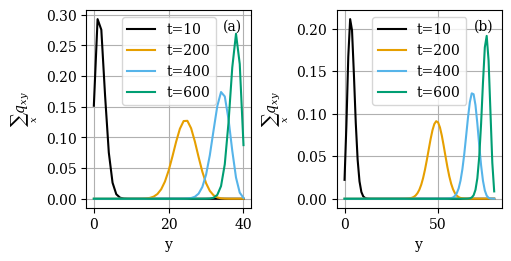

In [14]:
f, (ax1, ax2) = plt.subplots(ncols=2, layout="constrained", figsize=(5, 2.5))

ax1.set_prop_cycle(wong_cycle)
ax2.set_prop_cycle(wong_cycle)

for i in [10, 200, 400, 600]:
    ax2.plot(sol_200["80"]["y"][:,timeToIndex(sol_200["80"]["t"], i)], label="t={0}".format(i))

for i in [10, 200, 400, 600]:
    ax1.plot(sol_100["40"]["y"][:,timeToIndex(sol_100["40"]["t"], i)], label="t={0}".format(i))

ax1.grid(True)
ax1.set_xlabel("y")
ax1.set_ylabel("$\sum_{x}q_{xy}$")
ax1.legend(loc="upper center")

ax2.grid(True)
ax2.set_xlabel("y")
ax2.set_ylabel("$\sum_{x}q_{xy}$")
ax2.legend(loc="upper center")

ax1.annotate("(a)", (0.83, 0.9), xycoords="axes fraction")
ax2.annotate("(b)", (0.83, 0.9), xycoords="axes fraction")

## Plot f_slow

In [15]:
times = [1, 500, 1000, 1500]

fslow_100 = {
    j: np.array([
    pmfE(sol_100[i]["y"][:,timeToIndex(sol_100[i]["t"], j)])/j for i in sol_100.keys()
]) for j in times}

fslow_100_n = {
    j: np.array([
    pmfE(sol_100_n[i]["y"][:,timeToIndex(sol_100_n[i]["t"], j)])/j for i in sol_100_n.keys()
]) for j in times}

fslow_500 = {
    j: np.array([
    pmfE(sol_500[i]["y"][:,timeToIndex(sol_500[i]["t"], j)])/j for i in sol_500.keys()
]) for j in times}

N=np.arange(0,88)

#for A=100
fslow_det = {
    T: (N-N*np.exp(-T*R+T*R*R*N/(K*100)))/T for T in times}

#import fslow from the unsimplified model
with open("f_slow_100_unsimplified.dat", "rb") as f:
    fslow_100_uns = pickle.load(f)

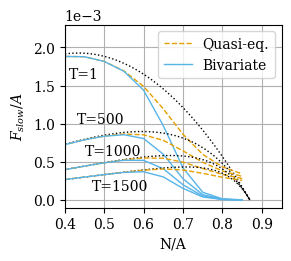

In [36]:
f, ax = plt.subplots(figsize=(2.8, 2.5), layout="constrained")

ax.set_prop_cycle(wong_cycle)
#ax2.set_prop_cycle(wong_cycle)

for t in times:
    ax.plot(N/100, fslow_det[t]/100, ":", linewidth=1, c=wong_colors[0])
    ax.plot(np.array([int(i) for i in sol_100.keys()])/100, fslow_100[t]/100, "--", linewidth=1, c=wong_colors[1])
    #ax.plot(np.array([int(i) for i in sol_500.keys()])/500, fslow_500[t]/500, "--", c=wong_colors[2])
    #ax.plot(np.array([int(i) for i in sol_100_n.keys()])/100, fslow_100_n[t]/100, "-.", linewidth=1, c=wong_colors[2])
    ax.plot(np.array([int(i) for i in sol_100.keys()])/100, fslow_100_uns[t]/100, "-", linewidth=1, c=wong_colors[2])

#for t in times:
#    ax2.plot(N/100, fslow_det[t]/100, ":", linewidth=1, c=wong_colors[0])
#    #ax2.plot(np.array([int(i) for i in sol_100.keys()])/100, fslow_100[t]/100, "-", linewidth=1, c=wong_colors[1])
#    #ax2.plot(np.array([int(i) for i in sol_500.keys()])/500, fslow_500[t]/500, "--", c=wong_colors[2])
#    ax2.plot(np.array([int(i) for i in sol_100_n.keys()])/100, fslow_100_n[t]/100, "--", linewidth=1, c=wong_colors[1])
#    ax2.plot(np.array([int(i) for i in sol_100.keys()])/100, fslow_100_uns[t]/100, "-", linewidth=1, c=wong_colors[2])

ax.grid(True)
ax.ticklabel_format(scilimits=(-2,5))
#ax.axis([0.4, 0.9, 0, 0.0023])
ax.set_ylim(top=0.0023)
ax.set_xlim(left=0.4, right=0.95)
ax.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

lines=ax.get_lines()

ax.legend([lines[1], lines[2], lines[3]], ["Quasi-eq.", "Bivariate"], loc="upper right")
ax.set_xlabel("N/A")
ax.set_ylabel("$F_{slow}/A$")

ax.annotate("T=1", (0.41, 0.0016), xycoords="data", color="black")
ax.annotate("T=500", (0.43, 0.001), xycoords="data", color="black")
ax.annotate("T=1000", (0.45, 0.00058), xycoords="data", color="black")
ax.annotate("T=1500", (0.47, 0.00012), xycoords="data", color="black")

################

#ax2.grid(True)
#ax2.ticklabel_format(scilimits=(-2,5))
#ax.axis([0.4, 0.9, 0, 0.0023])
#ax2.set_ylim(top=0.0023)
#ax2.set_xlim(left=0.4, right=0.95)
#ax2.set_xticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

#lines=ax2.get_lines()

#ax2.legend([lines[1], lines[2], lines[3]], ["Uni., num.", "Bivariate"], loc="upper right")
#ax2.set_xlabel("N/A")
#ax2.set_ylabel("$F_{slow}/A$")

plt.savefig("fslow_stochastic.pdf")